Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


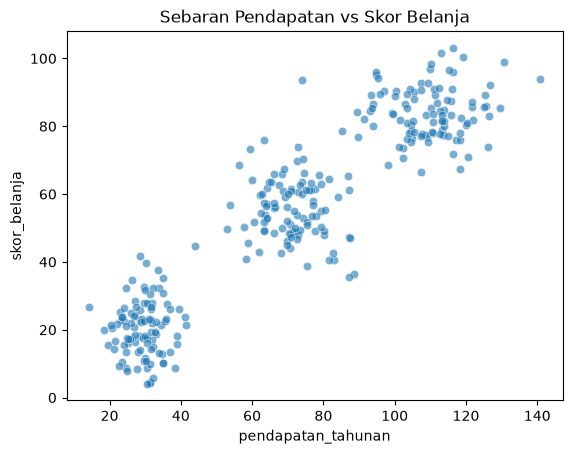

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
print('Shape:', df.shape)
print(df.describe().round(2))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [0. 0.]
Std setelah scaling : [1. 1.]


In [4]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


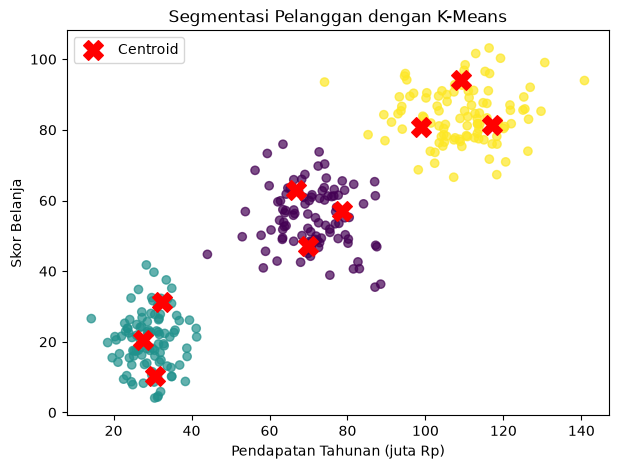


Cluster 1:
Jumlah pelanggan: 99
Rata-rata pendapatan tahunan: 70.99
Rata-rata skor belanja: 55.05
Rata-rata usia: 39.16
Distribusi gender:
gender
L    0.54
P    0.46
Name: proportion, dtype: float64

Cluster 2:
Jumlah pelanggan: 100
Rata-rata pendapatan tahunan: 29.31
Rata-rata skor belanja: 20.27
Rata-rata usia: 42.33
Distribusi gender:
gender
L    0.57
P    0.43
Name: proportion, dtype: float64

Cluster 3:
Jumlah pelanggan: 101
Rata-rata pendapatan tahunan: 109.20
Rata-rata skor belanja: 84.08
Rata-rata usia: 44.65
Distribusi gender:
gender
L    0.54
P    0.46
Name: proportion, dtype: float64


In [11]:
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
c=df['cluster'], cmap='viridis', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1],
c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()

# Interpretasikan tiap cluster, misalnya:
# Cluster 0 = pendapatan rendah, belanja rendah -> segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi -> segmen 'Boros/Premium'

#interpret each cluster
for i in range(3):
    cluster_data = df[df['cluster'] == i]
    print(f"\nCluster {i+1}:")
    print(f"Jumlah pelanggan: {len(cluster_data)}")
    print(f"Rata-rata pendapatan tahunan: {cluster_data['pendapatan_tahunan'].mean():.2f}")
    print(f"Rata-rata skor belanja: {cluster_data['skor_belanja'].mean():.2f}")
    print(f"Rata-rata usia: {cluster_data['usia'].mean():.2f}")
    print(f"Distribusi gender:\n{cluster_data['gender'].value_counts(normalize=True).round(2)}")

Berdasarkan hasil clustering, didapatkan 3 cluster pelanggan, yaitu cluster 1 (hemat), 2 (menengah), dan 3 (premium).

didapatkan juga rerata pendapatan tahunan,skor belanja, dan rata rata usia beserta distribusi gendernya.

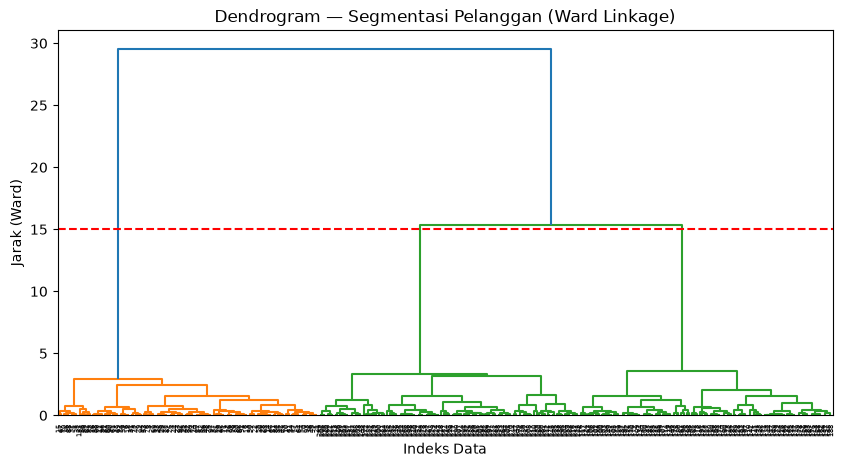

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()

Berdasarkan grafik, didapatkan 3 cluster segmentasi pembeli, Grafik ini selaras dengan metode Elbow dan algoritma K-Means. Didapat kesimpulan bahwa data terbagi secara alami menjadi tiga segmentasi pelanggan.

# Kesimpulan

Pada praktikum ini, saya telah melakukan analisa data, preprocessing data dengan menggunakan scaler, dan mengolah datanya menggunakan algoritma K-Means menjadi 3 cluster pelanggan. Hasil ini dibuktikan dengan hierarchial clustering yang menghasilkan jumlah cluster yang sama. Hasil pengolahan ini dapat digunakan lebih lanjut untuk melakukan analisa pelanggan dengan data-data terbaru.